In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data with the correct encoding
file_path = 'LLM Responses_APQC.csv'
try:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')
except UnicodeDecodeError:
    # Fallback if ISO-8859-1 doesn't work for your specific system
    df = pd.read_csv(file_path, encoding='cp1252')

def clean_text(text):
    """Normalizes text for fair comparison."""
    if pd.isna(text): return ""
    text = str(text).lower()
    
    # Replace common encoding artifacts like 'Ð' with a space or dash
    text = text.replace('ð', '-') 
    
    # Keep only alphanumeric characters and decimals for comparison
    text = re.sub(r'[^a-z0-9.]', ' ', text) 
    
    # Remove extra whitespace
    return re.sub(r'\s+', ' ', text).strip()

def calculate_similarity(str1, str2):
    """Calculates word-overlap similarity (Jaccard)."""
    set1 = set(clean_text(str1).split())
    set2 = set(clean_text(str2).split())
    if not set1 and not set2: return 1.0
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# 2. Run Comparison
llm_cols = ['LLM1', 'LLM2', 'LLM3']
target = 'Golden answer'

results = []
for col in llm_cols:
    # Exact Match Check (Normalized)
    df[f'{col}_is_exact'] = df.apply(lambda r: clean_text(r[col]) == clean_text(r[target]), axis=1)
    # Fuzzy Similarity Check
    df[f'{col}_similarity'] = df.apply(lambda r: calculate_similarity(r[col], r[target]), axis=1)
    
    results.append({
        'Model': col,
        'Exact Match (%)': df[f'{col}_is_exact'].mean() * 100,
        'Fuzzy Similarity (%)': df[f'{col}_similarity'].mean() * 100
    })


  Model  Exact Match (%)  Fuzzy Similarity (%)
0  LLM1         9.523810             56.724596
1  LLM2        33.333333             71.106589
2  LLM3         4.761905             43.112651


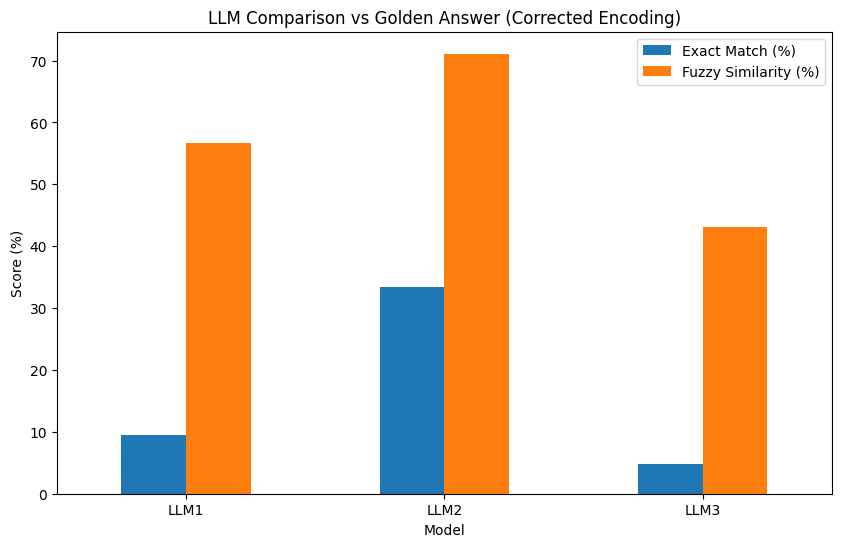

In [4]:

# 3. Output and Visualization
summary_df = pd.DataFrame(results)
print(summary_df)

summary_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('LLM Comparison vs Golden Answer (Corrected Encoding)')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.show()

In [6]:
!pip install pandas rouge-score sentence-transformers matplotlib seaborn

  Using cached rouge_score-0.1.2-py3-none-any.whl
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 8.6 MB/s  0:00:00
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sentence-transformers]


In [9]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util

# 1. SETUP & DATA LOADING
file_path = 'LLM Responses_APQC.csv'
# Using ISO-8859-1 to avoid the UnicodeDecodeError
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Initialize ROUGE scorer and Semantic Model
# 'all-MiniLM-L6-v2' is fast and accurate for business text
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
model = SentenceTransformer('all-MiniLM-L6-v2')

def normalize_text(text):
    """Basic cleaning: lowercase, remove special artifacts, and extra spaces."""
    if pd.isna(text): return ""
    text = str(text).lower()
    text = text.replace('ð', ' ') # Clean encoding artifacts
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 2. EVALUATION FUNCTIONS
def get_rouge_l(text, reference):
    """Calculates ROUGE-L score (Sequence/Ordering similarity)."""
    scores = scorer.score(normalize_text(reference), normalize_text(text))
    return scores['rougeL'].fmeasure * 100

def get_semantic_sim(text, reference):
    """Calculates Cosine Similarity (Meaning/Contextual similarity)."""
    t_clean = normalize_text(text)
    r_clean = normalize_text(reference)
    if not t_clean or not r_clean: return 0.0
    
    emb1 = model.encode(t_clean, convert_to_tensor=True)
    emb2 = model.encode(r_clean, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item() * 100

# 3. RUNNING THE ANALYSIS
llm_cols = ['LLM1', 'LLM2', 'LLM3']
target = 'Golden answer'

all_results = []

for col in llm_cols:
    # Workflow 1: Exact Match (Normalized)
    df[f'{col}_Exact'] = df.apply(lambda r: normalize_text(r[col]) == normalize_text(r[target]), axis=1)
    
    # Workflow 2: ROUGE-L (Sequence)
    df[f'{col}_ROUGE'] = df.apply(lambda r: get_rouge_l(r[col], r[target]), axis=1)
    
    # Workflow 3: Semantic Similarity (Meaning)
    df[f'{col}_Semantic'] = df.apply(lambda r: get_semantic_sim(r[col], r[target]), axis=1)
    
    # Aggregate stats
    all_results.append({
        'Model': col,
        'Exact Match (%)': df[f'{col}_Exact'].mean() * 100,
        'Sequence (ROUGE-L) %': df[f'{col}_ROUGE'].mean(),
        'Semantic (Meaning) %': df[f'{col}_Semantic'].mean()
    })



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Performance Summary ---
  Model  Exact Match (%)  Sequence (ROUGE-L) %  Semantic (Meaning) %
0  LLM1             9.52                 67.93                 87.34
1  LLM2            33.33                 79.81                 90.92
2  LLM3             4.76                 57.14                 80.19


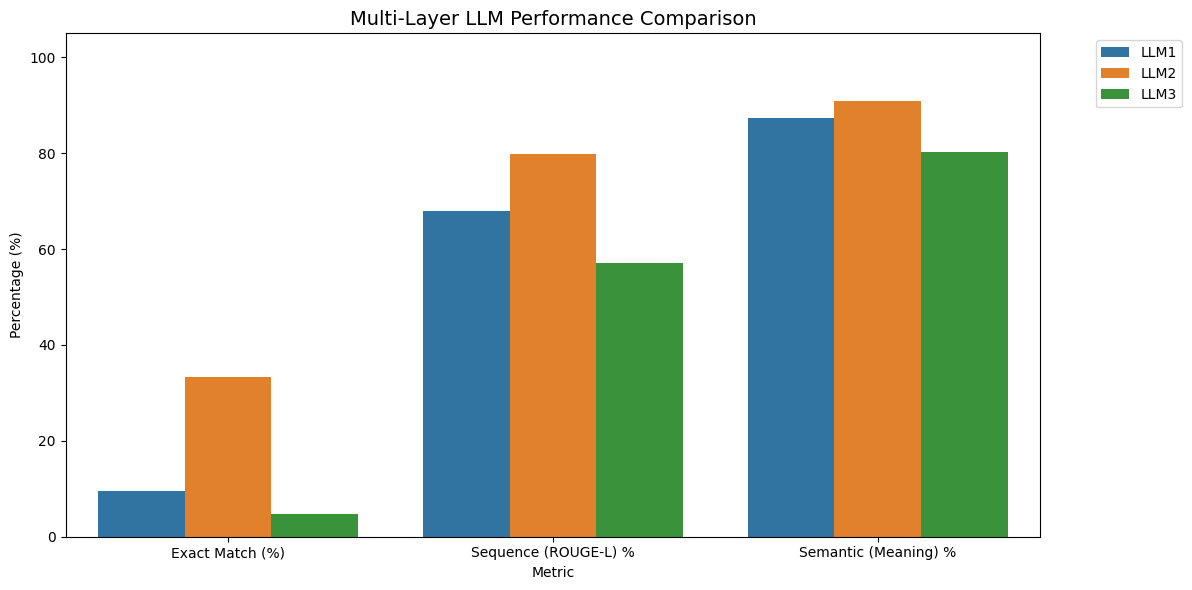

In [8]:
# 4. RESULTS & VISUALIZATION
summary_df = pd.DataFrame(all_results)
print("--- Performance Summary ---")
print(summary_df.round(2))

# Visualization
summary_melted = summary_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_melted, x='Metric', y='Score', hue='Model')
plt.title('Multi-Layer LLM Performance Comparison', fontsize=14)
plt.ylim(0, 105)
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. EXPORT RESULTS
# df.to_csv('LLM_Detailed_Audit.csv', index=False)